# 08 · Superconductivity: the complete public companion analysis

This notebook is the inspectable companion to the confidential Michelin campaign. It reads the recorded UCI Superconductivity artifacts and follows the same order as the industrial analysis:
1. frequency selection and SHAP refinement,
2. backbone transfer and baseline comparisons,
3. full-data explanations and stability, and
4. prediction intervals.

The public campaign keeps the industrial split, seeds, ranking operators, noise probes, refinement rule, model configurations, and m-split uncertainty settings.  
The UCI target remains in Kelvin until the split is drawn; its mean and population standard deviation are then estimated on the training target and applied unchanged to validation, calibration, and test.  
Only the candidate grid is adapted from the 316-variable industrial table to the 81-variable public table.  
The notebook does not silently turn row order into production time: chronological-window, record-index retraining, industrial category, RMC-correlation, k-SII interaction, and bootstrap split-location analyses are marked as out of scope below.  
Saved outputs and visualizations are directly viewable in this committed notebook. Rerunning campaign-dependent cells requires the retained full-campaign artifacts; from a clean checkout, use `make demo` for the lighter end-to-end execution on the same bundled dataset.

### Setup

In [1]:
import hashlib
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from tqdm import TqdmWarning

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)
    import shap as shap_lib
from xopa.explain import (
    drift_by_index,
    drift_by_output,
    explanation_diagnostics,
    global_importance,
    top_k_persistence,
)

from _shared import (
    BACKBONES,
    BACKBONE_COLORS,
    BACKBONE_LABELS,
    DOUBLE_COL,
    METHODS,
    METHOD_COLORS,
    METHOD_LABELS,
    N,
    ONE_HALF_COL,
    OPERATORS,
    OPERATOR_LABELS,
    PROBE_COLOR,
    ROOT,
    SINGLE_COL,
    SUPERCON_CAMPAIGN_DIR,
    init_notebook,
    jload,
)
from _shared import run_dir as campaign_run_dir

In [2]:
SET_ORDER = ["all_features", "boruta_confirmed", "rffs_summary_d_plus", "rffs_summary_d_parsimonious"]


def run_dir(backbone: str, kind: str):
    """Resolve one stage of the recorded public campaign."""
    return campaign_run_dir(backbone, kind, campaign=SUPERCON_CAMPAIGN_DIR)


mapping = pd.read_csv(ROOT / "public-datasets/superconductivity/xopa/superconductivity_mapping.csv")
REAL_NAME = dict(zip(mapping["xopa_name"], mapping["original"], strict=True))


def pretty(name: str) -> str:
    """Restore the original UCI descriptor name for display."""
    return REAL_NAME.get(name, name).replace("_", " ")


pd.set_option("display.width", 180)

FIG_DIR, savefig = init_notebook("08_superconductivity", campaign=SUPERCON_CAMPAIGN_DIR)

campaign: supercon-scale-full-rffs-4backbones-xgb-analyses-v2-2026-08-20
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity


## Recorded campaign contract

Before calculating a result, the notebook checks the public file hash, dimensions, column schema, stage manifests, and split assignments. The same source table and split must feed RFFS, baselines, model comparison, explanations, and conformal prediction.

In [3]:
public_path = ROOT / "public-datasets/superconductivity/xopa/superconductivity_xopa.csv"
public_data = pd.read_csv(public_path)
rffs_dirs = {b: run_dir(b, "rffs") for b in BACKBONES}
stage_dirs = {
    "baselines": run_dir("xgboost", "baselines"),
    "conformal": run_dir("xgboost", "conformal"),
    "explain": run_dir("xgboost", "explain"),
    "comparison": run_dir("xgboost", "comparison"),
}
reference_identity = jload(rffs_dirs["xgboost"] / "dataset_identity.json")
expected_columns = reference_identity["feature_names"] + [reference_identity["target"]]
actual_hash = hashlib.sha256(public_path.read_bytes()).hexdigest()
assert actual_hash == reference_identity["sha256"], "public source hash differs from the recorded campaign"
assert list(public_data.columns) == expected_columns
assert list(public_data.shape) == reference_identity["raw_shape"]

for label, path in [("xgboost RFFS", rffs_dirs["xgboost"]), *stage_dirs.items()]:
    identity = jload(path / "dataset_identity.json")
    assert identity["sha256"] == reference_identity["sha256"], f"{label}: source identity mismatch"

def assignments(path: Path) -> pd.DataFrame:
    return pd.read_csv(path / "split_assignments.csv").sort_values("row_id").reset_index(drop=True)

reference_assignments = assignments(rffs_dirs["xgboost"])
for label, path in [(b, rffs_dirs[b]) for b in BACKBONES] + list(stage_dirs.items()):
    pd.testing.assert_frame_equal(reference_assignments, assignments(path), check_dtype=False)

def target_transform(path: Path) -> tuple[bool, float, float]:
    with np.load(path / "preprocessing.npz") as artifact:
        return (
            bool(artifact["target_standardized"]),
            float(artifact["target_mean"]),
            float(artifact["target_scale"]),
        )

reference_transform = target_transform(rffs_dirs["xgboost"])
train_ids = reference_assignments.loc[reference_assignments["split"] == "train", "row_id"]
expected_mean = float(public_data.loc[train_ids, reference_identity["target"]].mean())
expected_scale = float(public_data.loc[train_ids, reference_identity["target"]].std(ddof=0))
assert reference_transform[0] is True
np.testing.assert_allclose(reference_transform[1:], (expected_mean, expected_scale), rtol=0, atol=1e-12)
for label, path in [(b, rffs_dirs[b]) for b in BACKBONES] + list(stage_dirs.items()):
    observed_transform = target_transform(path)
    assert observed_transform[0] is True, f"{label}: target standardization is disabled"
    np.testing.assert_allclose(observed_transform[1:], reference_transform[1:], rtol=0, atol=1e-12)

protocol_manifest = jload(rffs_dirs["xgboost"] / "manifest.json")
protocol_config = protocol_manifest["config"]
protocol_table = pd.Series(
    {
        "source SHA-256": reference_identity["sha256"],
        "records / predictors": f"{len(public_data):,} / {len(expected_columns) - 1}",
        "split ratios": protocol_config["split"]["ratios"],
        "split seed": protocol_config["split"]["seed"],
        "target transform": "training mean / population standard deviation",
        "training target mean (K)": f"{reference_transform[1]:.6f}",
        "training target std. (K)": f"{reference_transform[2]:.6f}",
        "candidate grid": protocol_config["ffs"]["grid"],
        "FFS repetitions Q": protocol_config["ffs"]["q_iterations"],
        "subsample fraction rho": protocol_config["ffs"]["rho"],
        "frequency threshold tau": protocol_config["ffs"]["tau"],
        "SFS repeats / epsilon": f"{protocol_config['sfs']['n_repeats']} / {protocol_config['sfs']['epsilon']}",
        "conformal shuffles M": protocol_config["conformal"]["m"],
    },
    name="recorded value",
)
display(protocol_table.to_frame())
print("identity and split checks passed for every recorded stage")

,recorded value
source SHA-256,fbc4781d33c0c4a722438f8fad50ea791afd245ffddac3...
records / predictors,"21,263 / 81"
split ratios,"[0.7, 0.075, 0.075, 0.15]"
split seed,42
target transform,training mean / population standard deviation
training target mean (K),34.737074
training target std. (K),34.382583
candidate grid,"[80, 70, 60, 50, 40, 30]"
FFS repetitions Q,10
subsample fraction rho,0.7


identity and split checks passed for every recorded stage


## 1. Feature selection and refinement

The first public stage follows the industrial order: compare the operator-by-dimension validation grid, inspect the frequency survivors and noise probes, then follow the SHAP-ordered refinement path.

In [4]:
grids = {
    b: {
        op: pd.read_csv(rffs_dirs[b] / f"grid_eval_{op}.csv").set_index("K")
        for op in OPERATORS
    }
    for b in BACKBONES
}
freqs = {b: pd.read_csv(rffs_dirs[b] / "selection_frequency.csv") for b in BACKBONES}
summaries = {b: jload(rffs_dirs[b] / "rffs_summary.json") for b in BACKBONES}
Q = int(freqs["xgboost"]["Q"].iloc[0])
GRID = sorted(grids["xgboost"]["rfe"].index.tolist(), reverse=True)
assert GRID == [80, 70, 60, 50, 40, 30]

headline_rows = []
for backbone in BACKBONES:
    summary = summaries[backbone]
    winner = summary["winner"]
    d_plus = int(summary["d_plus"])
    d_pars = int(summary["d_parsimonious"])
    test_metrics = summary["test_metrics"]
    d_plus_key = f"rffs_d_plus_{d_plus}"
    d_pars_key = f"rffs_d_parsimonious_{d_pars}"
    assert d_plus_key in test_metrics and d_pars_key in test_metrics
    d_star = int(grids[backbone][winner["operator"]].loc[winner["K"], "d_star"])
    headline_rows.append(
        {
            "backbone": BACKBONE_LABELS[backbone],
            "winner": OPERATOR_LABELS[winner["operator"]],
            "K": winner["K"],
            "d_star": d_star,
            "d_plus": d_plus,
            "d_pars": d_pars,
            "test R2 (d_plus)": test_metrics[d_plus_key]["r2"],
            "test MSE (d_plus)": test_metrics[d_plus_key]["mse"],
            "test R2 (d_pars)": test_metrics[d_pars_key]["r2"],
            "test MSE (d_pars)": test_metrics[d_pars_key]["mse"],
        }
    )
headline = pd.DataFrame(headline_rows).set_index("backbone")
display(headline.round(4))

,winner,K,d_star,d_plus,d_pars,test R2 (d_plus),test MSE (d_plus),test R2 (d_pars),test MSE (d_pars)
backbone,,,,,,,,,
XGBoost,RFE,40,33,29,26,0.9157,0.0815,0.9170,0.0802
Random forest,RFE,30,27,25,21,0.9127,0.0843,0.9135,0.0836
LightGBM,Model importance,60,55,55,32,0.9143,0.0828,0.9132,0.0839
MLP,Model importance,40,37,33,21,0.9013,0.0953,0.9054,0.0914


### Validation grid: operator × K for all four backbones

Cell colour is validation MSE, the annotation is the number of frequency survivors d_star, and the outlined cell is the recorded winner.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_grid_val_mse_all_backbones.pdf/.png


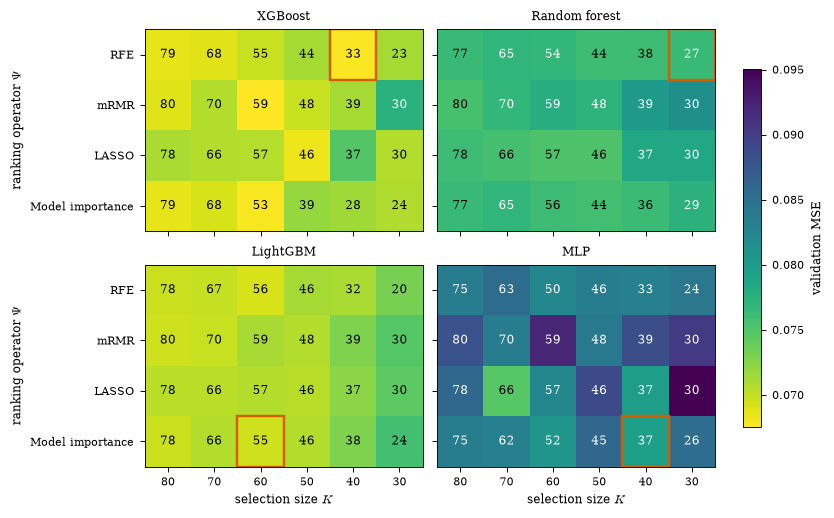

In [5]:
for backbone in BACKBONES:
    for operator in OPERATORS:
        grid = grids[backbone][operator]
        missing_columns = {"val_mse", "d_star"} - set(grid.columns)
        if missing_columns:
            raise ValueError(f"{backbone}/{operator} grid is missing columns: {sorted(missing_columns)}")
        if not np.isfinite(grid["val_mse"]).all() or (grid["val_mse"] < 0).any():
            raise ValueError(f"{backbone}/{operator} validation MSE values must be finite and non-negative")

fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.6), sharex=True, sharey=True)
vmin = min(grids[b][op]["val_mse"].min() for b in BACKBONES for op in OPERATORS)
vmax = max(grids[b][op]["val_mse"].max() for b in BACKBONES for op in OPERATORS)
for ax, backbone in zip(axes.ravel(), BACKBONES, strict=True):
    matrix = np.array([[grids[backbone][op].loc[k, "val_mse"] for k in GRID] for op in OPERATORS])
    im = ax.imshow(matrix, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")
    for i, op in enumerate(OPERATORS):
        for j, k in enumerate(GRID):
            d_star = int(grids[backbone][op].loc[k, "d_star"])
            red, green, blue, _ = im.cmap(im.norm(matrix[i, j]))
            luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
            text_color = "black" if luminance > 0.6 else "white"
            ax.text(j, i, str(d_star), ha="center", va="center", fontsize=8, color=text_color)
    winner = summaries[backbone]["winner"]
    ax.add_patch(plt.Rectangle((GRID.index(winner["K"]) - 0.5, OPERATORS.index(winner["operator"]) - 0.5), 1, 1, fill=False, edgecolor=PROBE_COLOR, lw=1.6))
    ax.set_title(BACKBONE_LABELS[backbone])
    ax.set_xticks(range(len(GRID)), GRID)
    ax.set_yticks(range(len(OPERATORS)), [OPERATOR_LABELS[o] for o in OPERATORS])
for ax in axes[-1]:
    ax.set_xlabel(f"selection size {N['K']}")
axes[0, 0].set_ylabel(f"ranking operator {N['psi']}")
axes[1, 0].set_ylabel(f"ranking operator {N['psi']}")
fig.colorbar(im, ax=axes, label="validation MSE", shrink=0.82)
savefig(fig, "supercon_grid_val_mse_all_backbones")
plt.show()

### SFS paths

The SFS curves use the recorded SHAP ordering at each backbone's winning frequency-selection cell. The vertical lines identify the validation-optimal d_plus and the 2% tolerance-based d_pars prefix.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_sfs_curves_all_backbones.pdf/.png


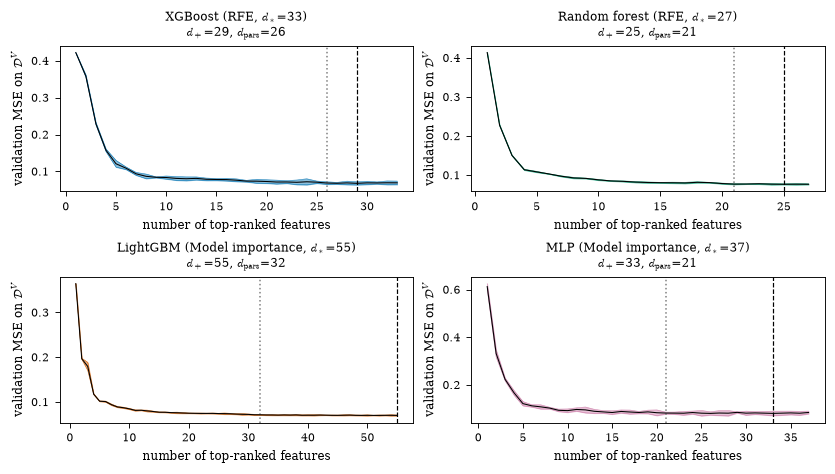

In [6]:
curves = {b: pd.read_csv(rffs_dirs[b] / "sfs_curve.csv") for b in BACKBONES}
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.2))
for ax, backbone in zip(axes.ravel(), BACKBONES, strict=True):
    curve = curves[backbone].sort_values("k")
    summary = summaries[backbone]
    winner = summary["winner"]
    d_star = int(grids[backbone][winner["operator"]].loc[winner["K"], "d_star"])
    k = curve["k"].to_numpy(dtype=int)
    mean = curve["mse_mean"].to_numpy(dtype=float)
    std = curve["mse_std"].to_numpy(dtype=float)
    expected_k = np.arange(1, d_star + 1)
    if not np.array_equal(k, expected_k):
        raise ValueError(f"{backbone}: expected a complete SFS path from 1 to d_star={d_star}, got {k[0]} to {k[-1]}")
    if not np.isfinite(mean).all() or not np.isfinite(std).all() or (std < 0).any():
        raise ValueError(f"{backbone}: invalid SFS mean or standard deviation")
    band_lower = mean - 3.0 * std
    band_upper = mean + 3.0 * std
    color = BACKBONE_COLORS[backbone]
    ax.fill_between(k, band_lower, band_upper, facecolor=color, alpha=0.45, edgecolor=color, linewidth=0.45, zorder=1)
    ax.plot(k, band_lower, color=color, lw=0.35, alpha=0.9, zorder=2)
    ax.plot(k, band_upper, color=color, lw=0.35, alpha=0.9, zorder=2)
    ax.plot(k, mean, color="black", lw=0.7, zorder=3)
    ax.axvline(summary["d_plus"], color="black", ls="--", lw=0.8)
    ax.axvline(summary["d_parsimonious"], color="gray", ls=":", lw=1.0)
    ax.set_title(
        f"{BACKBONE_LABELS[backbone]} "
        f"({OPERATOR_LABELS[winner['operator']]}, {N['d_star']}={d_star})\n"
        f"{N['d_plus']}={summary['d_plus']}, $d_{{\mathrm{{pars}}}}$={summary['d_parsimonious']}"
    )
    ax.set_xlabel("number of top-ranked features")
    ax.set_ylabel(f"validation MSE on {N['D_V']}")
savefig(fig, "supercon_sfs_curves_all_backbones")
plt.show()

### Frequency survivors and known-noise probes

At each winner cell, the dashed line is tau=0.8 and the dotted line is the largest synthetic-probe frequency.  
A solid bar clears the fixed frequency threshold and a faded bar is retained by the ranking but not by the frequency filter.  
The public descriptor names are intentionally not used as industrial categories.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_frequency_profiles_all_backbones.pdf/.png


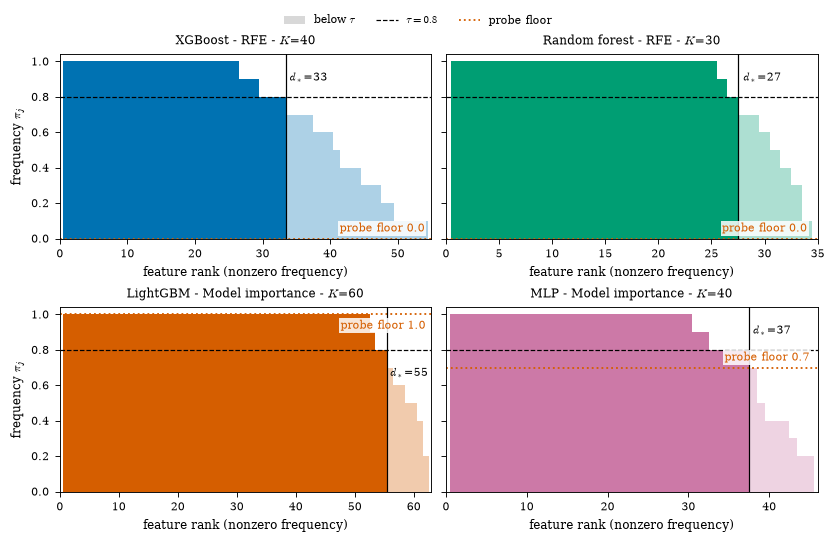

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.6), sharey=True)
tau_count = int(np.ceil(0.8 * Q))
for ax, backbone in zip(axes.ravel(), BACKBONES, strict=True):
    summary = summaries[backbone]
    winner = summary["winner"]
    cell = freqs[backbone].query("operator == @winner['operator'] and K == @winner['K']")
    real = cell[~cell["is_probe"]].query("frequency > 0").sort_values("frequency", ascending=False).reset_index(drop=True)
    probes = cell[cell["is_probe"]]
    ranks = np.arange(1, len(real) + 1)
    survives = (real["count"] >= tau_count).to_numpy()
    ax.bar(ranks[survives], real.loc[survives, "frequency"], width=1.0, color=BACKBONE_COLORS[backbone], lw=0)
    ax.bar(ranks[~survives], real.loc[~survives, "frequency"], width=1.0, color=BACKBONE_COLORS[backbone], alpha=0.32, lw=0)
    probe_floor = float(probes["frequency"].max()) if len(probes) else 0.0
    ax.axhline(0.8, color="black", ls="--", lw=0.8)
    ax.axhline(probe_floor, color=PROBE_COLOR, ls=":", lw=1.2)
    d_star = int(survives.sum())
    ax.axvline(d_star + 0.5, color="black", lw=0.8)
    n_features = len(real)
    if probe_floor > 0.9:
        floor_y, floor_va, dstar_y = probe_floor - 0.03, "top", 0.70
    else:
        floor_y, floor_va, dstar_y = probe_floor + 0.025, "bottom", 0.94
    ax.text(n_features, floor_y, f"probe floor {probe_floor:.1f}",
            ha="right", va=floor_va, fontsize=7, color=PROBE_COLOR,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.0})
    ax.text(d_star + max(1.0, 0.012 * n_features), dstar_y,
            f"{N['d_star']}={d_star}", ha="left", va="top", fontsize=7.5)
    ax.set_title(
        f"{BACKBONE_LABELS[backbone]} - {OPERATOR_LABELS[winner['operator']]} - "
        f"{N['K']}={winner['K']}"
    )
    ax.set_xlabel("feature rank (nonzero frequency)")
    ax.set_ylim(0, 1.04)
    ax.set_xlim(0, n_features + 1)
axes[0, 0].set_ylabel(f"frequency {N['pi_j']}")
axes[1, 0].set_ylabel(f"frequency {N['pi_j']}")
handles = [
    plt.Rectangle((0, 0), 1, 1, fc="#888888", alpha=0.32, label="below " + N["tau"]),
    Line2D([], [], color="black", ls="--", lw=0.8, label=r"$\tau=0.8$"),
    Line2D([], [], color=PROBE_COLOR, ls=":", lw=1.2, label="probe floor"),
]
fig.legend(handles=handles, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.05))
savefig(fig, "supercon_frequency_profiles_all_backbones")
plt.show()

## 2. Backbone comparison and baselines

The industrial analysis next asks whether the selected representation transfers to other predictive backbones and how it compares with all-variable and Boruta references.

In [8]:
comparison = pd.read_csv(stage_dirs["comparison"] / "model_comparison.csv")
baseline_dir = stage_dirs["baselines"]
decision = jload(baseline_dir / "boruta_decision.json")
boruta_history = pd.read_csv(baseline_dir / "boruta_decision_history.csv")
feature_sets = jload(stage_dirs["comparison"] / "feature_sets.json")
SET_LABELS = {
    "all_features": "all 81",
    "boruta_confirmed": f"Boruta {len(decision['confirmed'])}",
    "rffs_summary_d_plus": r"RFFS $d_{+}$",
    "rffs_summary_d_parsimonious": r"RFFS $d_{\mathrm{pars}}$",
}
assert set(comparison["feature_set"]) == set(SET_ORDER)
assert set(comparison["backbone"]) == set(BACKBONES)
assert len(decision["confirmed"]) == len(feature_sets["boruta_confirmed"])
assert len(decision["tentative"]) == 0
assert set(feature_sets["rffs_summary_d_plus"]) == set(summaries["xgboost"]["final_features"])
required_columns = {"feature_set", "backbone", "split", "mse", "r2"}
missing_columns = required_columns - set(comparison.columns)
if missing_columns:
    raise ValueError(f"comparison artifact is missing columns: {sorted(missing_columns)}")
test_rows = comparison.query("split == 'test'").copy()
expected_pairs = {(feature_set, backbone) for feature_set in SET_ORDER for backbone in BACKBONES}
observed_pairs = set(zip(test_rows["feature_set"], test_rows["backbone"], strict=True))
if len(test_rows) != len(expected_pairs) or observed_pairs != expected_pairs:
    raise ValueError("comparison artifact must contain exactly one test row per feature-set/backbone pair")
if not np.isfinite(test_rows[["mse", "r2"]].to_numpy()).all() or (test_rows["mse"] < 0).any():
    raise ValueError("test metrics must be finite and MSE values non-negative")
test_mse = test_rows.pivot(index="feature_set", columns="backbone", values="mse").loc[SET_ORDER, BACKBONES]
test_r2 = test_rows.pivot(index="feature_set", columns="backbone", values="r2").loc[SET_ORDER, BACKBONES]
test_display = pd.concat({"MSE": test_mse, "R2": test_r2}, axis=1, names=["metric"])
display(test_display.rename(index=SET_LABELS, columns=BACKBONE_LABELS).round(4))
print(f"Boruta: {len(decision['confirmed'])} confirmed / {len(decision['tentative'])} tentative / {len(decision['rejected'])} rejected after {decision['n_iter']} iterations")

metric                       MSE                                     R2                               
backbone                 XGBoost Random forest LightGBM     MLP XGBoost Random forest LightGBM     MLP
feature_set                                                                                           
all 81                    0.0817        0.0822   0.0798  0.0996  0.9154        0.9149   0.9175  0.8969
Boruta 74                 0.0832        0.0828   0.0801  0.1012  0.9139        0.9143   0.9171  0.8953
RFFS $d_{+}$              0.0815        0.0841   0.0814  0.1004  0.9157        0.9129   0.9157  0.8961
RFFS $d_{\mathrm{pars}}$  0.0802        0.0841   0.0820  0.1050  0.9170        0.9130   0.9152  0.8913

Boruta: 74 confirmed / 0 tentative / 7 rejected after 77 iterations


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_test_mse_by_backbone_and_set.pdf/.png


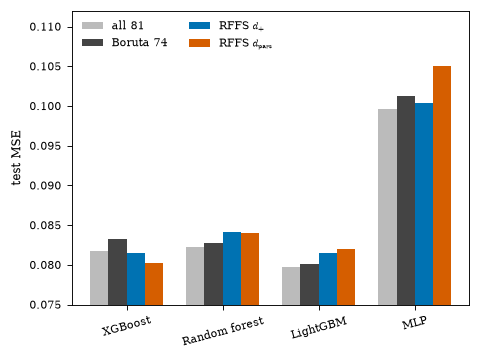

In [9]:
fig, ax = plt.subplots(figsize=(4.25, 3.15))
x = np.arange(len(BACKBONES))
width = 0.19
colors = ["#BBBBBB", "#444444", "#0072B2", "#D55E00"]
for i, feature_set in enumerate(SET_ORDER):
    ax.bar(x + (i - 1.5) * width, test_mse.loc[feature_set], width, color=colors[i], label=SET_LABELS[feature_set])
ax.set_xticks(x, [BACKBONE_LABELS[b] for b in BACKBONES], rotation=15)
ax.set_ylabel("test MSE")
ax.set_ylim(0.075, 0.112)
ax.legend(loc="upper left", ncol=2, frameon=False)
savefig(fig, "supercon_test_mse_by_backbone_and_set")
plt.show()

,method,n_features,val_mse
6,RFFS,29,0.0668
2,FFS (mRMR),59,0.0675
4,FFS (RFE),33,0.0677
5,FFS (Model importance),53,0.0678
3,FFS (LASSO),46,0.0682
1,Boruta,74,0.0685
0,All variables,81,0.0693


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_selection_frontier.pdf/.png


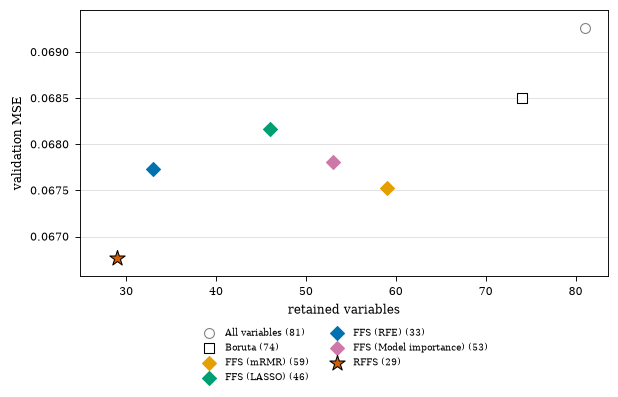

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_boruta_trajectory.pdf/.png


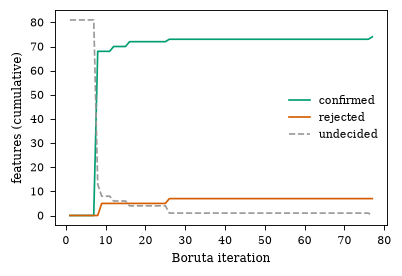

In [10]:
# XGBoost validation frontier: the four preliminary FFS winners and the reference sets.
frontier_rows = []
for operator in OPERATORS:
    grid = grids["xgboost"][operator]
    best = grid.sort_values(["val_mse", "K"]).iloc[0]
    frontier_rows.append({"method": f"FFS ({OPERATOR_LABELS[operator]})", "n_features": int(best["d_star"]), "val_mse": float(best["val_mse"])})
for feature_set, label in [("all_features", "All variables"), ("boruta_confirmed", "Boruta"), ("rffs_summary_d_plus", "RFFS")]:
    row = comparison.query("split == 'val' and backbone == 'xgboost' and feature_set == @feature_set").iloc[0]
    frontier_rows.append({"method": label, "n_features": int(row["n_features"]), "val_mse": float(row["mse"])})
frontier = pd.DataFrame(frontier_rows)
frontier_method_order = [
    "All variables",
    "Boruta",
    "FFS (mRMR)",
    "FFS (LASSO)",
    "FFS (RFE)",
    "FFS (Model importance)",
    "RFFS",
]
frontier_method_styles = {
    "All variables": ("#7F7F7F", "o", False),
    "Boruta": ("#000000", "s", False),
    "FFS (mRMR)": ("#E69F00", "D", True),
    "FFS (LASSO)": ("#009E73", "D", True),
    "FFS (RFE)": ("#0072B2", "D", True),
    "FFS (Model importance)": ("#CC79A7", "D", True),
    "RFFS": ("#D55E00", "*", True),
}
if frontier["method"].duplicated().any() or set(frontier["method"]) != set(frontier_method_order):
    raise ValueError(f"unexpected public frontier methods: {frontier['method'].tolist()}")
frontier_indexed = frontier.set_index("method").loc[frontier_method_order]
if not np.isfinite(frontier["val_mse"]).all() or (frontier["val_mse"] < 0).any():
    raise ValueError("frontier validation MSE values must be finite and non-negative")
display(frontier_indexed.reset_index().sort_values("val_mse").round(4))
with mpl.rc_context({"figure.constrained_layout.use": False}):
    fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 3.5))
handles = []
for method, row in frontier_indexed.iterrows():
    color, marker, filled = frontier_method_styles[method]
    point = ax.scatter(
        row["n_features"],
        row["val_mse"],
        s=110 if method == "RFFS" else 42,
        marker=marker,
        facecolor=color if filled else "white",
        edgecolor="black" if method == "RFFS" else color,
        linewidth=0.7,
        zorder=4 if method == "RFFS" else 3,
        label=f"{method} ({int(row['n_features'])})",
    )
    handles.append(point)
x_min, x_max = frontier["n_features"].agg(["min", "max"])
y_min, y_max = frontier["val_mse"].agg(["min", "max"])
x_span = max(float(x_max - x_min), 1.0)
y_span = max(float(y_max - y_min), 1e-3)
ax.set_xlabel("retained variables")
ax.set_ylabel("validation MSE")
ax.set_xlim(float(x_min) - 0.08 * x_span, float(x_max) + 0.05 * x_span)
ax.set_ylim(float(y_min) - 0.08 * y_span, float(y_max) + 0.08 * y_span)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.5, zorder=0)
ax.legend(handles=handles, ncol=2, fontsize=6, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False, borderaxespad=0.0)
fig.subplots_adjust(bottom=0.32)
savefig(fig, "supercon_selection_frontier")
plt.show()

per_iter = boruta_history.groupby("iteration")[["accepted_this_iteration", "rejected_this_iteration"]].sum().cumsum()
undecided = len(decision["confirmed"]) + len(decision["tentative"]) + len(decision["rejected"]) - per_iter.sum(axis=1)
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.4))
ax.plot(per_iter.index, per_iter["accepted_this_iteration"], color="#009E73", label="confirmed")
ax.plot(per_iter.index, per_iter["rejected_this_iteration"], color=PROBE_COLOR, label="rejected")
ax.plot(undecided.index, undecided, color="#999999", ls="--", label="undecided")
ax.set_xlabel("Boruta iteration")
ax.set_ylabel("features (cumulative)")
ax.legend()
savefig(fig, "supercon_boruta_trajectory")
plt.show()

## 3. Full-data explanations and stability

The public explanation stage is fixed to the recorded XGBoost $d_{+}=29$ model.  
It explains all 21,263 records, validates SHAP additivity, restores the original UCI descriptor names, and recomputes the recorded rank-stability, row-order drift, target-bin drift, and monotonicity diagnostics.

In [11]:
explain_dir = stage_dirs["explain"]
bundle = np.load(explain_dir / "shap_bundle.npz", allow_pickle=True)
row_ids = np.asarray(bundle["row_ids"], dtype=int)
order = np.argsort(row_ids)
feature_names = [str(feature) for feature in bundle["feature_names"]]
final_features = summaries["xgboost"]["final_features"]
assert feature_names == final_features
shap_values = pd.DataFrame(bundle["shap_values"][order], index=row_ids[order], columns=feature_names)
feature_values = pd.DataFrame(bundle["feature_values"][order], index=row_ids[order], columns=feature_names)
y_true = pd.Series(bundle["y_true"][order], index=row_ids[order], name="target")
stored_predictions = np.asarray(bundle["predictions"])[order]
assert np.array_equal(row_ids[order], np.arange(len(public_data)))
kelvin_target = public_data.iloc[row_ids[order]][reference_identity["target"]].to_numpy()
expected_standardized_target = (kelvin_target - reference_transform[1]) / reference_transform[2]
assert np.allclose(expected_standardized_target, y_true.to_numpy())
phi0_by_row = stored_predictions - shap_values.sum(axis=1).to_numpy()
phi0 = float(phi0_by_row.mean())
max_additivity_error = float(np.abs(phi0_by_row - phi0).max())
assert max_additivity_error < 1e-5, f"SHAP additivity error is {max_additivity_error:.2e}"
importance = global_importance(shap_values)
recorded_importance = pd.read_csv(explain_dir / "global_importance.csv", index_col=0).iloc[:, 0]
assert list(recorded_importance.index) == list(importance.index)
assert np.allclose(recorded_importance.to_numpy(), importance.to_numpy(), atol=1e-10)
importance_table = importance.head(10).rename("mean |SHAP|").to_frame()
importance_table.index = [pretty(name) for name in importance_table.index]
display(importance_table.round(4))
print(f"records: {len(shap_values):,}; features: {len(feature_names)}")
print(f"SHAP base value: {phi0:.6f}; maximum additivity deviation: {max_additivity_error:.2e}")

,mean |SHAP|
range ThermalConductivity,0.4295
range atomic radius,0.0999
wtd gmean Valence,0.0691
wtd mean Valence,0.0597
wtd gmean ThermalConductivity,0.0530
wtd std ThermalConductivity,0.0519
std atomic mass,0.0500
wtd std ElectronAffinity,0.0406
wtd mean ThermalConductivity,0.0402
gmean Density,0.0391


records: 21,263; features: 29
SHAP base value: 0.000033; maximum additivity deviation: 3.00e-06


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_explanation_summary.pdf/.png


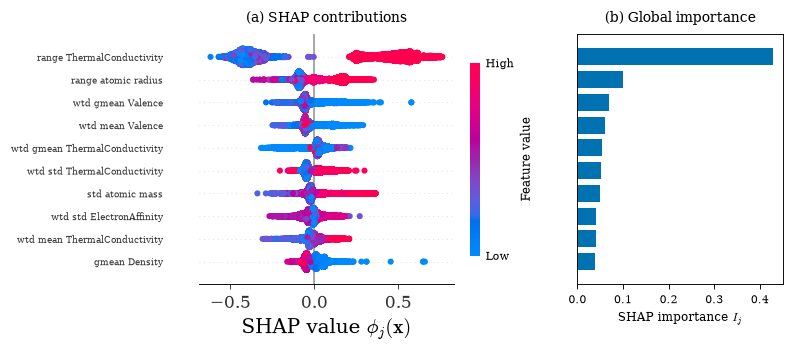

In [12]:
top = importance.head(10).sort_values()
assert len(top) == 10
display_values = feature_values.rename(columns=pretty)
random_state = np.random.get_state()
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="The NumPy global RNG was seeded.*", category=FutureWarning)
    np.random.seed(42)
plt.close("all")
try:
    with mpl.rc_context({"figure.constrained_layout.use": False}):
        fig = plt.figure(figsize=(DOUBLE_COL, 3.25))
        ax_swarm = fig.add_axes([0.27, 0.17, 0.31, 0.70])
        plt.sca(ax_swarm)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="The NumPy global RNG was seeded.*", category=FutureWarning)
            warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout.*", category=UserWarning)
            shap_lib.summary_plot(
                shap_values.rename(columns=pretty).to_numpy(),
                display_values,
                max_display=10,
                color_bar=False,
                show=False,
                plot_size=None,
            )
        ax_swarm.set_position([0.27, 0.17, 0.31, 0.70])
        ax_swarm.set_xlabel(r"SHAP value $\phi_j(\mathbf{x})$")
        ax_swarm.set_title("(a) SHAP contributions", fontsize=9, pad=8)
        ax_swarm.tick_params(axis="y", labelsize=6.2)

        color_axis = fig.add_axes([0.60, 0.25, 0.012, 0.54])
        color_map = shap_lib.plots.colors.red_blue
        color_scale = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap=color_map)
        colorbar = fig.colorbar(color_scale, cax=color_axis, ticks=[0, 1])
        colorbar.set_ticklabels(["Low", "High"])
        colorbar.set_label("Feature value", fontsize=8)
        colorbar.ax.tick_params(labelsize=7, length=0)
        colorbar.outline.set_visible(False)

        ax_importance = fig.add_axes([0.73, 0.17, 0.25, 0.70], sharey=ax_swarm)
        ax_importance.barh(range(len(top)), top.to_numpy(), color="#0072B2", height=0.75)
        ax_importance.tick_params(axis="y", left=False, labelleft=False)
        ax_importance.set_xlabel(f"SHAP importance {N['I_j']}")
        ax_importance.set_title("(b) Global importance", fontsize=9, pad=8)
        savefig(fig, "supercon_explanation_summary")
        plt.show()
finally:
    np.random.set_state(random_state)

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_drift_heatmaps.pdf/.png


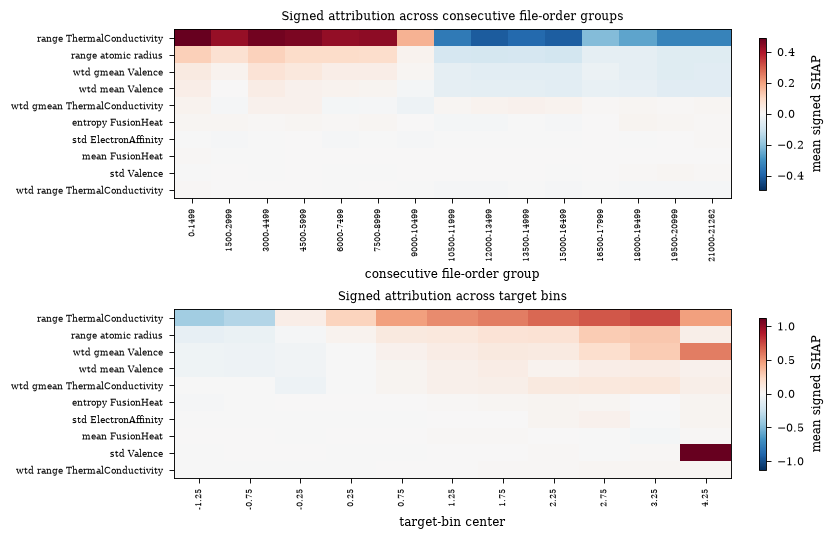

In [13]:
GROUP_SIZE = int(jload(explain_dir / "manifest.json")["config"]["explain"]["group_size"])
BIN_WIDTH = float(jload(explain_dir / "manifest.json")["config"]["explain"]["bin_width"])
recorded_idx = pd.read_csv(explain_dir / "drift_by_index.csv", index_col=0)
recorded_out = pd.read_csv(explain_dir / "drift_by_output.csv", index_col=0)
importance_order = list(importance.index)
display_features = importance_order[:5] + importance_order[-5:]
assert len(feature_names) == summaries["xgboost"]["d_plus"]
assert len(display_features) == 10
assert len(set(display_features)) == len(display_features)
drift_idx = drift_by_index(shap_values, display_features, group_size=GROUP_SIZE)
drift_out = drift_by_output(shap_values, display_features, y_true, bin_width=BIN_WIDTH)
assert list(recorded_idx.index) == display_features
assert list(recorded_out.index) == display_features
assert np.allclose(recorded_idx.to_numpy(), drift_idx.to_numpy(), atol=1e-10)
assert np.allclose(recorded_out.to_numpy(), drift_out.to_numpy(), atol=1e-10)
fig, axes = plt.subplots(2, 1, figsize=(DOUBLE_COL, 4.8))
for ax, drift, xlabel in ((axes[0], drift_idx, "consecutive file-order group"), (axes[1], drift_out, "target-bin center")):
    limit = float(np.nanmax(np.abs(drift.to_numpy())))
    im = ax.imshow(drift.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_yticks(range(len(drift.index)), [pretty(name) for name in drift.index], fontsize=6)
    ax.set_xticks(range(len(drift.columns)), drift.columns, rotation=90, fontsize=5.5)
    ax.set_xlabel(xlabel)
    fig.colorbar(im, ax=ax, label="mean signed SHAP", shrink=0.9)
axes[0].set_title("Signed attribution across consecutive file-order groups")
axes[1].set_title("Signed attribution across target bins")
savefig(fig, "supercon_drift_heatmaps")
plt.show()

,descriptors,definition
Heatmap display,10,5 highest and 5 lowest global mean absolute SHAP
Rank agreement,29,all selected descriptors
Top-5 persistence,5,global top 5 among all selected descriptors


,value
ranked features,29.0000
consecutive file-order groups,15.0000
median Spearman agreement,0.9468
minimum Spearman agreement,0.8798
median top-5 persistence,0.8000
minimum top-5 persistence,0.8000


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_stability_statistics.pdf/.png


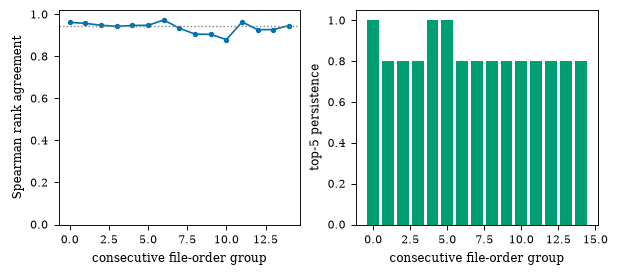

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_monotonicity_lollipop.pdf/.png


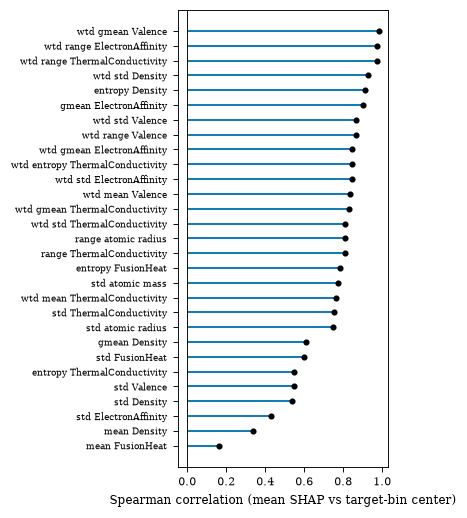

In [14]:
stability, _ = explanation_diagnostics(shap_values, y_true, group_size=GROUP_SIZE, bin_width=BIN_WIDTH)
recorded_top5 = pd.read_csv(explain_dir / "top5_persistence.csv")
recorded_monotonic = pd.read_csv(explain_dir / "monotonicity.csv", index_col=0).iloc[:, 0]
monotonic_features = list(recorded_monotonic.index)
_, monotonic = explanation_diagnostics(shap_values[monotonic_features], y_true, group_size=GROUP_SIZE, bin_width=BIN_WIDTH)
# The recorded top-five persistence is defined against the full selected model.
recomputed_top5 = top_k_persistence(shap_values, feature_names, group_size=GROUP_SIZE, k=5)
assert np.allclose(recorded_top5["top_5_persistence"].to_numpy(), recomputed_top5.to_numpy(), atol=1e-10)
assert list(recorded_monotonic.index) == list(monotonic.index)
assert np.allclose(recorded_monotonic.to_numpy(), monotonic.to_numpy(), atol=1e-10)
diagnostic_scope = pd.DataFrame({
    "descriptors": [len(display_features), len(feature_names), 5],
    "definition": [
        "5 highest and 5 lowest global mean absolute SHAP",
        "all selected descriptors",
        "global top 5 among all selected descriptors",
    ],
}, index=["Heatmap display", "Rank agreement", "Top-5 persistence"])
display(diagnostic_scope.style.set_caption("Attribution diagnostic scope"))
stability_summary = pd.Series({
    "ranked features": len(feature_names),
    "consecutive file-order groups": len(stability),
    "median Spearman agreement": stability.median(),
    "minimum Spearman agreement": stability.min(),
    "median top-5 persistence": recomputed_top5.median(),
    "minimum top-5 persistence": recomputed_top5.min(),
}, name="value")
display(stability_summary.to_frame().round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(ONE_HALF_COL, 2.4))
ax1.plot(stability.index, stability.to_numpy(), marker="o", ms=2.5, color="#0072B2")
ax1.axhline(stability.median(), color="gray", ls=":", lw=0.9)
ax1.set_xlabel("consecutive file-order group")
ax1.set_ylabel("Spearman rank agreement")
ax1.set_ylim(0, 1.02)
ax2.bar(recorded_top5["group"], recorded_top5["top_5_persistence"], color="#009E73", width=0.8)
ax2.set_xlabel("consecutive file-order group")
ax2.set_ylabel("top-5 persistence")
ax2.set_ylim(0, 1.05)
savefig(fig, "supercon_stability_statistics")
plt.show()

mono_sorted = monotonic.sort_values()
fig, ax = plt.subplots(figsize=(SINGLE_COL, 4.6))
ax.hlines(range(len(mono_sorted)), 0, mono_sorted.to_numpy(), color="#0072B2", lw=1.2)
ax.plot(mono_sorted.to_numpy(), range(len(mono_sorted)), "o", ms=3.0, color="black")
ax.set_yticks(range(len(mono_sorted)), [pretty(name) for name in mono_sorted.index], fontsize=6)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("Spearman correlation (mean SHAP vs target-bin center)")
savefig(fig, "supercon_monotonicity_lollipop")
plt.show()

### Interpretation boundary for the public explanation

The row-order heatmap is a descriptive diagnostic only: the UCI table has no Michelin-like production chronology, so no row-index feature, post-hoc window, or within-window coverage comparison is fitted.  
The package's industrial CTX/PV/RMC/WC/PRS labels are also not physical categories for these material descriptors, so category-composition and RMC-correlation plots are deliberately not reported.  
The public campaign records no k-SII interaction or bootstrap split-location artifacts, those analyses remain limited to the industrial campaign.

## 4. Uncertainty quantification

The final stage mirrors the industrial interval analysis: inspect exact per-test intervals, compare sharpness and target-bin coverage, then inspect the per-split calibration distribution and running averages.  
The public conditional-coverage file contains only the overall test group, which is checked rather than presented as a subgroup result.

In [15]:
uq_dir = stage_dirs["conformal"]
intervals = pd.read_csv(uq_dir / "test_intervals.csv")
checkpoints = pd.read_csv(uq_dir / "conformal_checkpoints.csv")
convergence = pd.read_csv(uq_dir / "conformal_convergence.csv")
conditional = pd.read_csv(uq_dir / "conditional_coverage.csv")
uq_metrics = jload(uq_dir / "uq_metrics.json")
required_checkpoint_columns = {"method", "M", "is_final", "q_hat", "picp", "mpiw", "wcc", "n_test", "nominal_coverage"}
assert required_checkpoint_columns.issubset(checkpoints.columns)
expected_checkpoints = [("scp", 100), ("scp", 500), ("scp", 2200), ("cqr", 100), ("cqr", 500), ("cqr", 2200)]
observed_checkpoints = list(checkpoints[["method", "M"]].itertuples(index=False, name=None))
assert observed_checkpoints == expected_checkpoints
assert set(uq_metrics) == set(METHODS)
for method in ("scp", "cqr"):
    final = checkpoints.query("method == @method and is_final").iloc[0]
    for column in ("q_hat", "picp", "mpiw", "wcc"):
        assert np.isclose(final[column], uq_metrics[method][column])
assert set(conditional["group"]) == {"overall"}

publication_uq = checkpoints[["method", "M", "q_hat", "picp", "mpiw", "wcc"]].copy()
publication_uq["method"] = publication_uq["method"].map(METHOD_LABELS)
publication_uq = publication_uq.rename(columns={"q_hat": "correction", "picp": "test PICP", "mpiw": "test MPIW"})
ensemble = pd.DataFrame([{"method": "ENS", "M": "—", "correction": uq_metrics["ens"]["z"], "test PICP": uq_metrics["ens"]["picp"], "test MPIW": uq_metrics["ens"]["mpiw"], "wcc": np.nan}])
publication_uq = pd.concat([publication_uq, ensemble], ignore_index=True)
display(publication_uq.round(4))
display(conditional.round(4))

,method,M,correction,test PICP,test MPIW,wcc
0,m-SCP,100,0.4240,0.8993,0.8480,0.8558
1,m-SCP,500,0.4243,0.8997,0.8486,0.8276
2,m-SCP,2200,0.4243,0.8997,0.8487,0.8276
3,m-CQR,100,0.0236,0.9072,1.0130,0.8558
4,m-CQR,500,0.0236,0.9072,1.0130,0.8401
5,m-CQR,2200,0.0235,0.9072,1.0128,0.8245
6,ENS,—,5.6900,0.9000,0.8053,NaN


,method,group,definition,n,picp,mpiw
0,scp,overall,all test rows,3189,0.8997,0.8487
1,cqr,overall,all test rows,3189,0.9072,1.0128
2,ens,overall,all test rows,3189,0.9000,0.8053


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_coverage_by_output_bin.pdf/.png


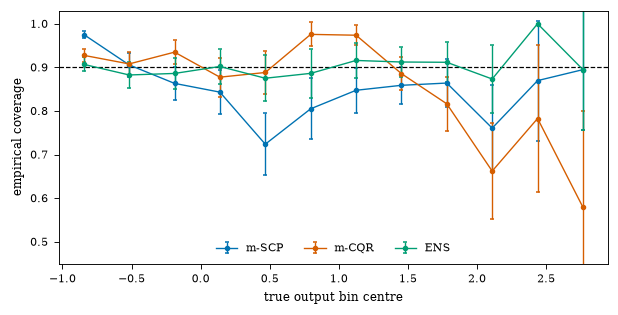

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_msplit_distribution_and_convergence.pdf/.png


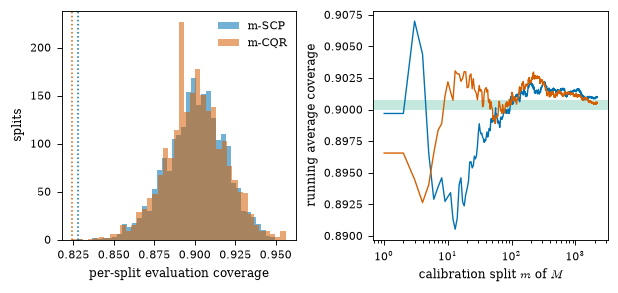

In [16]:
edges = np.linspace(intervals["y_true"].min(), intervals["y_true"].max(), 13)
fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 2.75))
for method in METHODS:
    block = intervals.query("method == @method")
    bins = pd.cut(block["y_true"], edges)
    grouped = block.groupby(bins, observed=True)["covered"]
    centers = [interval.mid for interval in grouped.mean().index]
    coverage = grouped.mean().to_numpy()
    n = grouped.count().to_numpy()
    half = 1.96 * np.sqrt(np.clip(coverage * (1 - coverage), 1e-9, None) / n)
    ax.errorbar(centers, coverage, yerr=half, marker="o", ms=2.6, lw=0.9, capsize=1.4, color=METHOD_COLORS[method], label=METHOD_LABELS[method])
ax.axhline(0.9, color="black", ls="--", lw=0.8)
ax.set_xlabel("true output bin centre")
ax.set_ylabel("empirical coverage")
ax.set_ylim(0.45, 1.03)
ax.legend(loc="lower center", ncol=3)
savefig(fig, "supercon_coverage_by_output_bin")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(ONE_HALF_COL, 2.55))
for method in ("scp", "cqr"):
    block = convergence.query("method == @method")
    ax1.hist(block["eval_coverage"], bins=40, alpha=0.55, color=METHOD_COLORS[method], label=METHOD_LABELS[method])
    ax2.plot(block["split_number"], block["running_coverage"], color=METHOD_COLORS[method], lw=0.9)
    ax2.axhspan(block["nominal_coverage"].iloc[0], block["finite_sample_upper"].iloc[0], color="#009E73", alpha=0.12, lw=0)
    ax1.axvline(uq_metrics[method]["wcc"], color=METHOD_COLORS[method], ls=":", lw=1.0)
ax1.set_xlabel("per-split evaluation coverage")
ax1.set_ylabel("splits")
ax1.legend()
ax2.set_xscale("log")
ax2.set_xlabel(f"calibration split $m$ of {N['M']}")
ax2.set_ylabel("running average coverage")
savefig(fig, "supercon_msplit_distribution_and_convergence")
plt.show()

## Compact public summary

This final panel is the small, paper-facing entry point. The figures above remain available for readers who want to audit each stage and are the source for the extended appendix.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/08_superconductivity/supercon_core_summary.pdf/.png


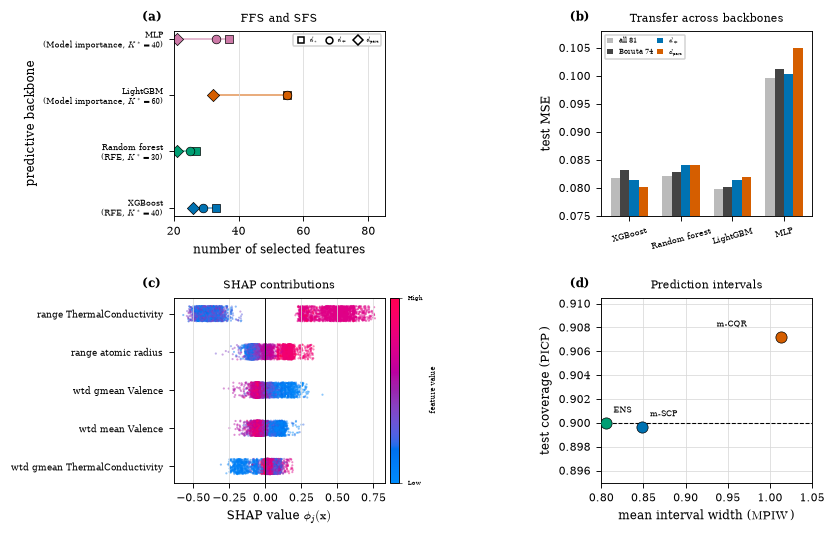

The public companion completed the four ordered core stages.
Interpretive scope: computational reproducibility on UCI data, not industrial validation or physical causality.


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.75), gridspec_kw={"hspace": 0.08, "wspace": 0.25})
for ax, label in zip(axes.ravel(), ["(a)", "(b)", "(c)", "(d)"], strict=True):
    ax.text(-0.15, 1.04, label, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom")

ax = axes[0, 0]
marker_styles = {"d_star": "s", "d_plus": "o", "d_pars": "D"}
y_positions = np.arange(len(BACKBONES))
for y, backbone in zip(y_positions, BACKBONES, strict=True):
    row = headline.loc[BACKBONE_LABELS[backbone]]
    dimensions = {"d_star": int(row["d_star"]), "d_plus": int(row["d_plus"]), "d_pars": int(row["d_pars"])}
    ordered = ["d_star", "d_plus", "d_pars"]
    ax.plot([dimensions[key] for key in ordered], [y] * len(ordered), color=BACKBONE_COLORS[backbone], alpha=0.55, lw=1.2, zorder=1)
    for key in ordered:
        ax.scatter(dimensions[key], y, s=32, marker=marker_styles[key], color=BACKBONE_COLORS[backbone], edgecolor="black", linewidth=0.45, zorder=2)
selection_labels = [
    f"{BACKBONE_LABELS[b]}\n"
    f"({OPERATOR_LABELS[summaries[b]['winner']['operator']]}, $K^*={summaries[b]['winner']['K']}$)"
    for b in BACKBONES
]
ax.set_yticks(y_positions, selection_labels, fontsize=5.4)
ax.set_xlabel("number of selected features")
ax.set_ylabel("predictive backbone")
ax.set_title("FFS and SFS", fontsize=7)
marker_handles = [
    Line2D([0], [0], marker="s", color="black", markerfacecolor="white", markeredgecolor="black", lw=0, markersize=4.5, label=r"$d_*$"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="white", markeredgecolor="black", lw=0, markersize=4.5, label=r"$d_+$"),
    Line2D([0], [0], marker="D", color="black", markerfacecolor="white", markeredgecolor="black", lw=0, markersize=4.5, label=r"$d_{\mathrm{pars}}$"),
]
ax.legend(handles=marker_handles, loc="upper right", ncol=3, fontsize=4.4, frameon=True, facecolor="white", framealpha=0.85, edgecolor="#CCCCCC", borderpad=0.25, handletextpad=0.25, columnspacing=0.55)
ax.set_xlim(20, 85)
ax.set_xticks([20, 40, 60, 80])
ax.grid(axis="x", color="#D9D9D9", linewidth=0.5)

ax = axes[0, 1]
core_sets = ["all_features", "boruta_confirmed", "rffs_summary_d_plus", "rffs_summary_d_parsimonious"]
set_labels = ["all 81", f"Boruta {len(decision['confirmed'])}", r"$d_+$", r"$d_{\mathrm{pars}}$"]
core_colors = ["#BBBBBB", "#444444", "#0072B2", "#D55E00"]
x = np.arange(len(BACKBONES))
width = 0.18
for i, (feature_set, color, label) in enumerate(zip(core_sets, core_colors, set_labels, strict=True)):
    bars = ax.bar(x + (i - 1.5) * width, test_mse.loc[feature_set], width, color=color, label=label)
ax.set_xticks(x, [BACKBONE_LABELS[b] for b in BACKBONES], rotation=15, fontsize=5.5)
ax.set_ylabel("test MSE")
ax.set_title(r"Transfer across backbones", fontsize=7)
ax.set_ylim(0.075, 0.108)
ax.legend(fontsize=4.6, ncol=2, loc="upper left", frameon=True, facecolor="white", framealpha=0.85, edgecolor="#CCCCCC", borderpad=0.3, handlelength=0.9, columnspacing=0.6)

ax = axes[1, 0]
top5 = importance.head(5).sort_values()
sample_idx = np.linspace(0, len(shap_values) - 1, min(4000, len(shap_values)), dtype=int)
rng = np.random.default_rng(42)
color_norm = mpl.colors.Normalize(vmin=0, vmax=1)
for y, feature in enumerate(top5.index):
    values = shap_values.iloc[sample_idx][feature].to_numpy()
    feature_rank = feature_values.iloc[sample_idx][feature].rank(pct=True).to_numpy()
    jitter = rng.uniform(-0.20, 0.20, size=len(values))
    ax.scatter(values, y + jitter, c=feature_rank, cmap=shap_lib.plots.colors.red_blue, norm=color_norm, s=2.0, alpha=0.45, linewidths=0, rasterized=True)
ax.axvline(0, color="black", lw=0.6)
ax.set_yticks(range(len(top5)), [pretty(name) for name in top5.index], fontsize=6.2)
ax.set_xlabel(r"SHAP value $\phi_j(\mathbf{x})$")
ax.set_title("SHAP contributions", fontsize=7)
scalar_map = mpl.cm.ScalarMappable(norm=color_norm, cmap=shap_lib.plots.colors.red_blue)
scalar_map.set_array([])
colorbar = fig.colorbar(scalar_map, ax=ax, pad=0.02, fraction=0.05)
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(["Low", "High"])
colorbar.set_label("feature value", fontsize=4.8)
colorbar.ax.tick_params(labelsize=4.0, width=0.4, length=2)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.5)

ax = axes[1, 1]
nominal = float(checkpoints["nominal_coverage"].iloc[0])
uq_offsets = {"scp": (5, 7), "cqr": (-42, 7), "ens": (5, 7)}
for method in METHODS:
    mpiw = uq_metrics[method]["mpiw"]
    picp = uq_metrics[method]["picp"]
    ax.scatter(mpiw, picp, s=54, color=METHOD_COLORS[method], edgecolor="black", linewidth=0.45, zorder=3)
    ax.annotate(METHOD_LABELS[method], (mpiw, picp), xytext=uq_offsets[method], textcoords="offset points", fontsize=5.5, ha="left")
ax.axhline(nominal, color="black", ls="--", lw=0.7)
ax.set_xlabel(r"mean interval width ($\operatorname{MPIW}$)")
ax.set_ylabel(r"test coverage ($\operatorname{PICP}$)")
ax.set_title("Prediction intervals", fontsize=7)
ax.set_xlim(0.80, 1.05)
ax.set_ylim(0.895, 0.9105)
ax.grid(color="#D9D9D9", linewidth=0.5)

savefig(fig, "supercon_core_summary")
plt.show()

print("The public companion completed the four ordered core stages.")
print("Interpretive scope: computational reproducibility on UCI data, not industrial validation or physical causality.")